🚀 SPAM CLASSIFIER

Install Dependencies    

In [2]:
!pip install -q pyngrok flask flask-cors scikit-learn pandas numpy matplotlib seaborn wordcloud

Download Dataset

In [3]:
import pandas as pd
import urllib.request, zipfile, os

print("=" * 60)
print("  📥  Downloading UCI SMS Spam Collection Dataset")
print("=" * 60)

DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
ZIP_PATH = "smsspamcollection.zip"
DATA_DIR = "spam_data"

try:
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    DATA_FILE = os.path.join(DATA_DIR, "SMSSpamCollection")
    df_raw = pd.read_csv(DATA_FILE, sep="\t", header=None,
                         names=["label", "message"], encoding="latin-1")
    print(f"✅  Downloaded!  Rows: {len(df_raw):,}  |  Cols: {df_raw.shape[1]}")
    print(df_raw.head(4).to_string(index=False))
except Exception as e:
    print(f"❌  Download failed: {e}")
    print("    Falling back to inline mini-dataset …")
    df_raw = pd.DataFrame({
        "label": ["ham","ham","spam","spam","ham","spam","ham","spam","ham"],
        "message": [
            "Hey are you free tonight?",
            "See you at the meeting tomorrow at 3pm",
            "WINNER!! You have been selected for a 1000 prize. Call now!",
            "FREE entry in 2 a weekly competition to win FA Cup final tickets",
            "Can you pick up groceries on your way home?",
            "URGENT: Your account is suspended. Verify now: http://bit.ly/xyz",
            "Lunch at 1pm works for me, see you there",
            "Congratulations ur mobile number has WON 2000 BONUS. Call 09061743810",
            "Are you coming to the party on Saturday?"
        ]
    })

print(f"\n📊  Label counts:\n{df_raw['label'].value_counts().to_string()}")

  📥  Downloading UCI SMS Spam Collection Dataset
✅  Downloaded!  Rows: 5,572  |  Cols: 2
label                                                                                                                                                     message
  ham                                             Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  ham                                                                                                                               Ok lar... Joking wif u oni...
 spam Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  ham                                                                                                           U dun say so early hor... U c already then say...

📊  Label counts:
label
ham     4825
spam     747


Dataset Exploration & Cleaning  

  📊  DATASET EXPLORATION

  Shape          : (5572, 2)
  Null values    : 0
  Duplicates     : 403
  Spam ratio     : 13.4%

  Avg length  — Ham : 72 chars
  Avg length  — Spam: 139 chars


/tmp/ipykernel_5734/1114278704.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([ham_wc, spam_wc], labels=["ham","spam"],
/tmp/ipykernel_5734/1114278704.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="label", y="digit_count",


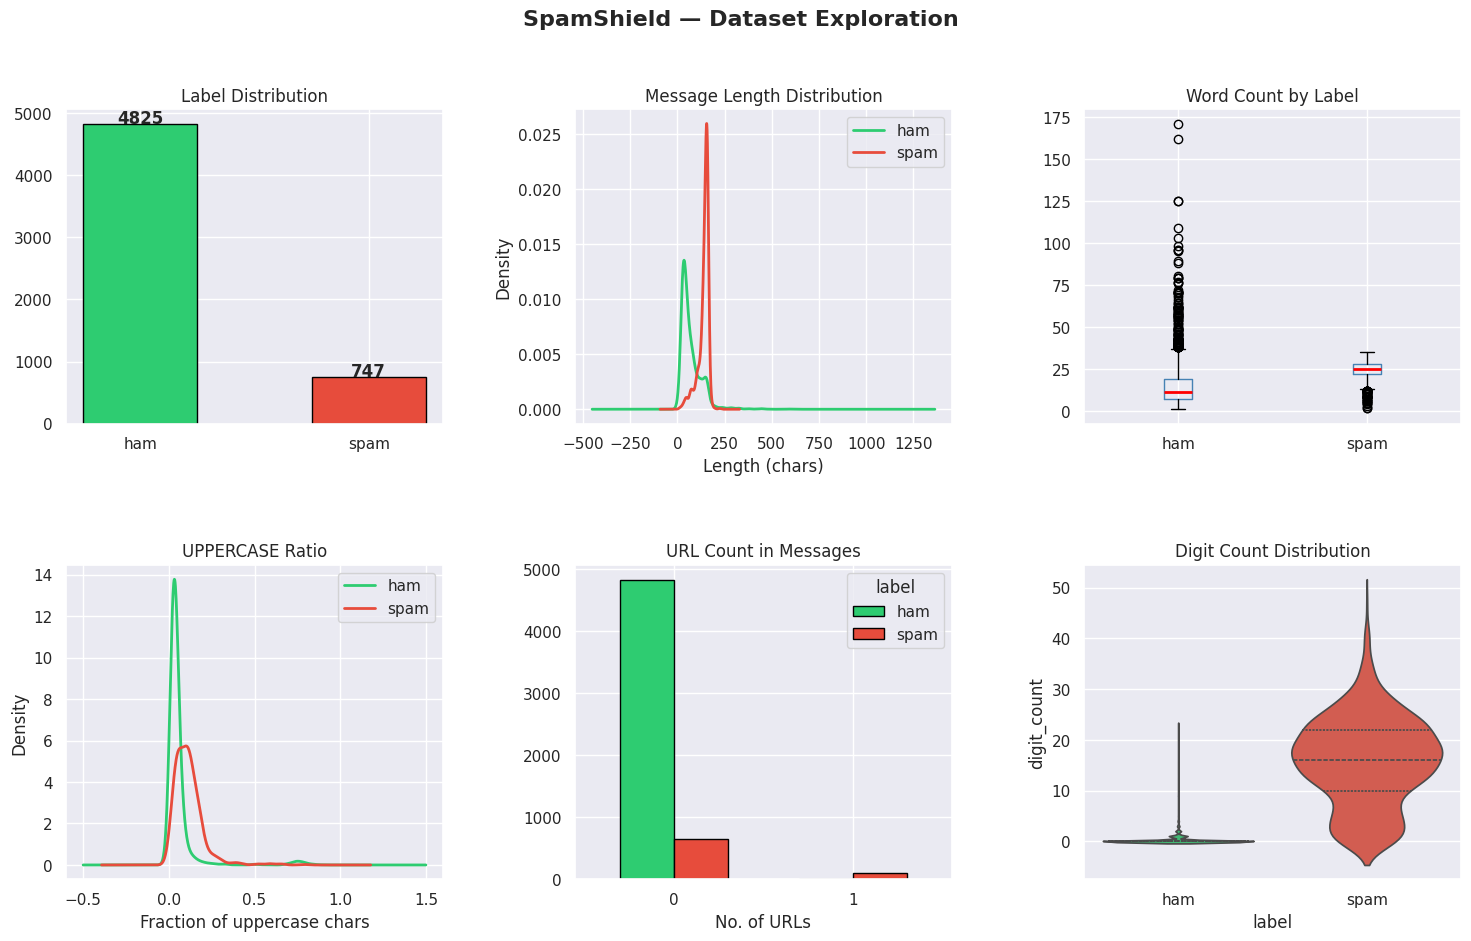

📸  Saved → eda_exploration.png


/tmp/ipykernel_5734/1114278704.py:94: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5734/1114278704.py:94: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5734/1114278704.py:95: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("wordclouds.png", dpi=100, bbox_inches="tight")
/tmp/ipykernel_5734/1114278704.py:95: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig("wordclouds.png", dpi=100, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu S

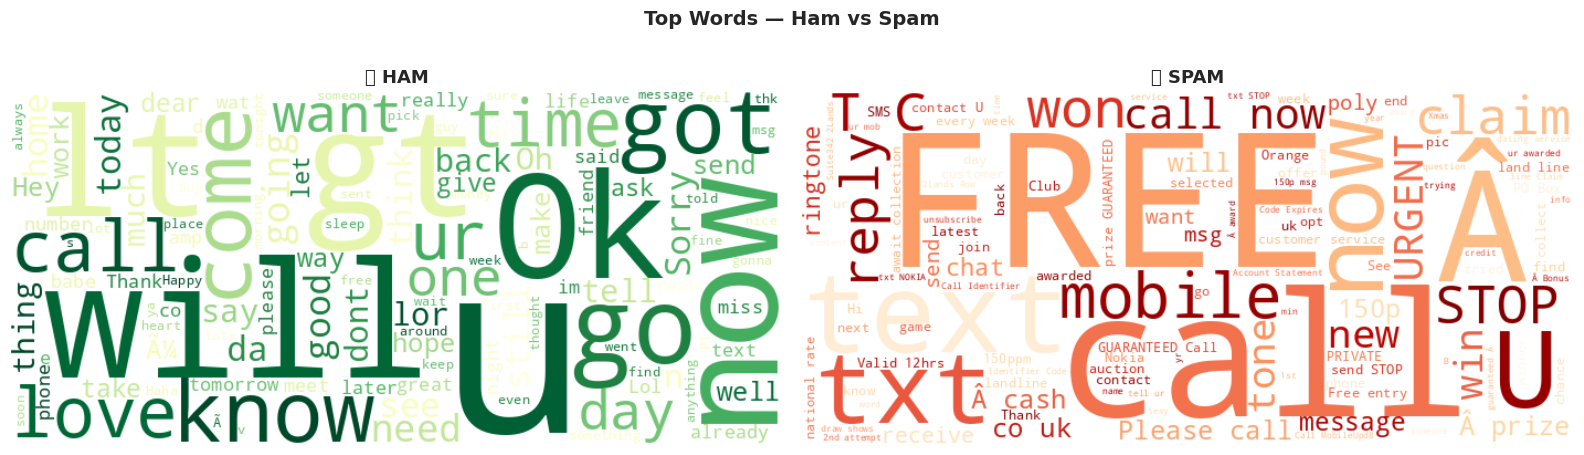

📸  Saved → wordclouds.png

🧹  Cleaning dataset …
✅  Before: 5,572  →  After cleaning: 5,169 rows
label                                                                                                                                                     message                                                                                                         clean_msg
  ham                                             Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...                         until jurong point crazy available only bugis great world buffet cine there got amore wat
  ham                                                                                                                               Ok lar... Joking wif u oni...                                                                                                lar joking wif oni
 spam Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. T

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
import re

sns.set_theme(style="darkgrid", palette="muted")

print("=" * 60)
print("  📊  DATASET EXPLORATION")
print("=" * 60)

df = df_raw.copy()
print(f"\n  Shape          : {df.shape}")
print(f"  Null values    : {df.isnull().sum().sum()}")
print(f"  Duplicates     : {df.duplicated().sum()}")
spam_ratio = df["label"].value_counts(normalize=True).get("spam", 0)
print(f"  Spam ratio     : {spam_ratio*100:.1f}%")

df["msg_len"]     = df["message"].apply(len)
df["word_count"]  = df["message"].apply(lambda x: len(x.split()))
df["url_count"]   = df["message"].apply(lambda x: len(re.findall(r"https?://\S+|www\.\S+", x)))
df["digit_count"] = df["message"].apply(lambda x: sum(c.isdigit() for c in x))
df["upper_ratio"] = df["message"].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))

print(f"\n  Avg length  — Ham : {df[df.label=='ham']['msg_len'].mean():.0f} chars")
print(f"  Avg length  — Spam: {df[df.label=='spam']['msg_len'].mean():.0f} chars")

palette = {"ham": "#2ecc71", "spam": "#e74c3c"}

fig = plt.figure(figsize=(18, 10))
fig.suptitle("SpamShield — Dataset Exploration", fontsize=16, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax0 = fig.add_subplot(gs[0, 0])
vc = df["label"].value_counts()
bars = ax0.bar(vc.index, vc.values,
               color=[palette[l] for l in vc.index], edgecolor="black", width=0.5)
ax0.set_title("Label Distribution")
for bar, v in zip(bars, vc.values):
    ax0.text(bar.get_x() + bar.get_width()/2, v + 15, str(v), ha="center", fontweight="bold")

ax1 = fig.add_subplot(gs[0, 1])
for lbl, grp in df.groupby("label"):
    grp["msg_len"].plot(kind="kde", ax=ax1, label=lbl, color=palette[lbl], linewidth=2)
ax1.set_title("Message Length Distribution")
ax1.set_xlabel("Length (chars)")
ax1.legend()

ax2 = fig.add_subplot(gs[0, 2])
ham_wc  = df[df.label=="ham"]["word_count"]
spam_wc = df[df.label=="spam"]["word_count"]
ax2.boxplot([ham_wc, spam_wc], labels=["ham","spam"],
            boxprops=dict(color="steelblue"),
            medianprops=dict(color="red", linewidth=2))
ax2.set_title("Word Count by Label")

ax3 = fig.add_subplot(gs[1, 0])
for lbl, grp in df.groupby("label"):
    grp["upper_ratio"].plot(kind="kde", ax=ax3, label=lbl, color=palette[lbl], linewidth=2)
ax3.set_title("UPPERCASE Ratio")
ax3.set_xlabel("Fraction of uppercase chars")
ax3.legend()

ax4 = fig.add_subplot(gs[1, 1])
url_tab = df.groupby(["label","url_count"]).size().unstack(fill_value=0)
url_tab.T.plot(kind="bar", ax=ax4,
               color=[palette["ham"], palette["spam"]],
               edgecolor="black", width=0.6)
ax4.set_title("URL Count in Messages")
ax4.set_xlabel("No. of URLs")
ax4.tick_params(axis="x", rotation=0)

ax5 = fig.add_subplot(gs[1, 2])
sns.violinplot(data=df, x="label", y="digit_count",
               palette=palette, ax=ax5, inner="quartile")
ax5.set_title("Digit Count Distribution")

plt.savefig("eda_exploration.png", dpi=100, bbox_inches="tight")
plt.show()
print("📸  Saved → eda_exploration.png")

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
fig2.suptitle("Top Words — Ham vs Spam", fontsize=14, fontweight="bold")
for ax, lbl, cmap in zip(axes2, ["ham","spam"], ["YlGn","OrRd"]):
    corpus = " ".join(df[df.label == lbl]["message"])
    if corpus.strip():
        wc = WordCloud(width=700, height=320, background_color="white",
                       colormap=cmap, max_words=120).generate(corpus)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{'✅ HAM' if lbl=='ham' else '🚫 SPAM'}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("wordclouds.png", dpi=100, bbox_inches="tight")
plt.show()
print("📸  Saved → wordclouds.png")

# Cleaning
print("\n🧹  Cleaning dataset …")
before = len(df)
df.drop_duplicates(inplace=True)
df.dropna(subset=["label","message"], inplace=True)
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})

STOP_W = {
    "the","and","is","in","it","to","a","of","for","on","are","this",
    "that","with","was","be","as","you","have","at","from","or","an",
    "but","not","they","we","what","so","if","about","up","out","can",
    "just","me","my","your","our","all","more","will","do","its","been"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " urltoken ", text)
    text = re.sub(r"\b\d{4,}\b", " numtoken ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [w for w in text.split() if len(w) > 2 and w not in STOP_W]
    return " ".join(tokens)

df["clean_msg"] = df["message"].apply(clean_text)
print(f"✅  Before: {before:,}  →  After cleaning: {len(df):,} rows")
print(df[["label","message","clean_msg"]].head(3).to_string(index=False))

Train / Test Split & Model Training

🔀  Train: 4,135  |  Test: 1,034

  Model                        Acc    Prec     Rec      F1     AUC
  Complement NB             0.9681  0.8224  0.9542  0.8834  0.9918
  Logistic Regression       0.9845  0.9832  0.8931  0.9360  0.9977
  Calibrated SVM            0.9903  0.9764  0.9466  0.9612  0.9988
  Random Forest             0.9845  1.0000  0.8779  0.9350  0.9975
  Gradient Boosting         0.9894  1.0000  0.9160  0.9562  0.9719

🤝  Training Voting Ensemble …
  Voting Ensemble           0.9894  0.9839  0.9313  0.9569  0.9983

🏆  Best Model : Calibrated SVM  (F1=0.9612  AUC=0.9988)

📋  Detailed Report — Calibrated SVM:
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       903
        Spam       0.98      0.95      0.96       131

    accuracy                           0.99      1034
   macro avg       0.98      0.97      0.98      1034
weighted avg       0.99      0.99      0.99      1034



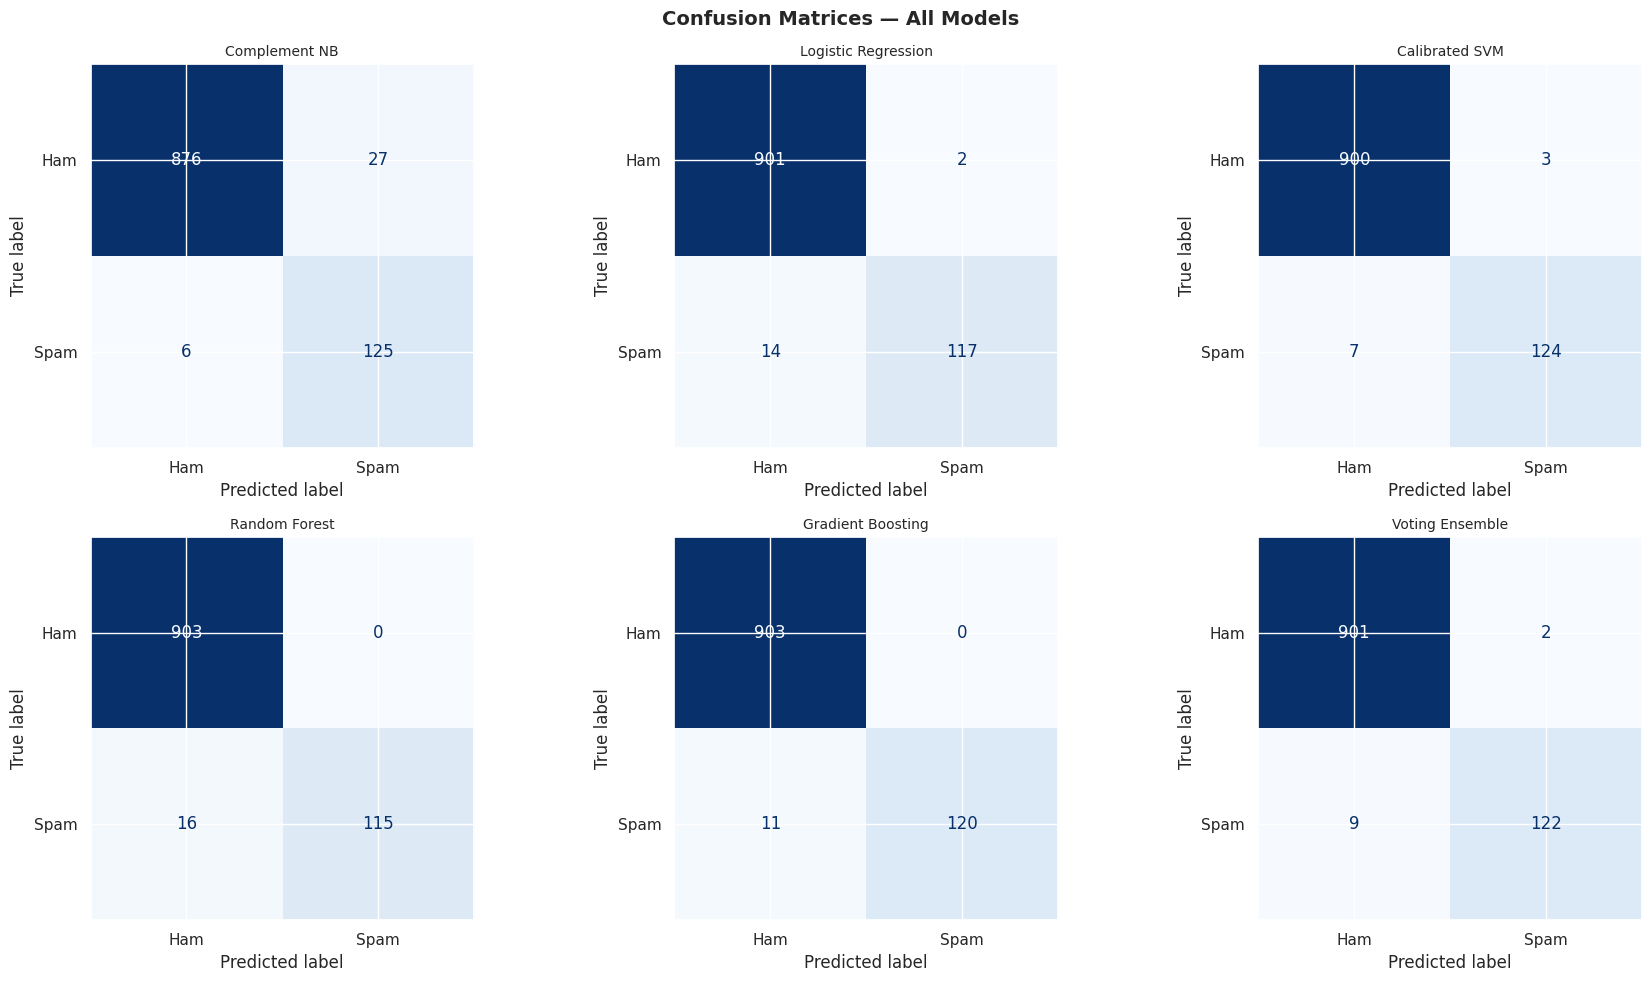

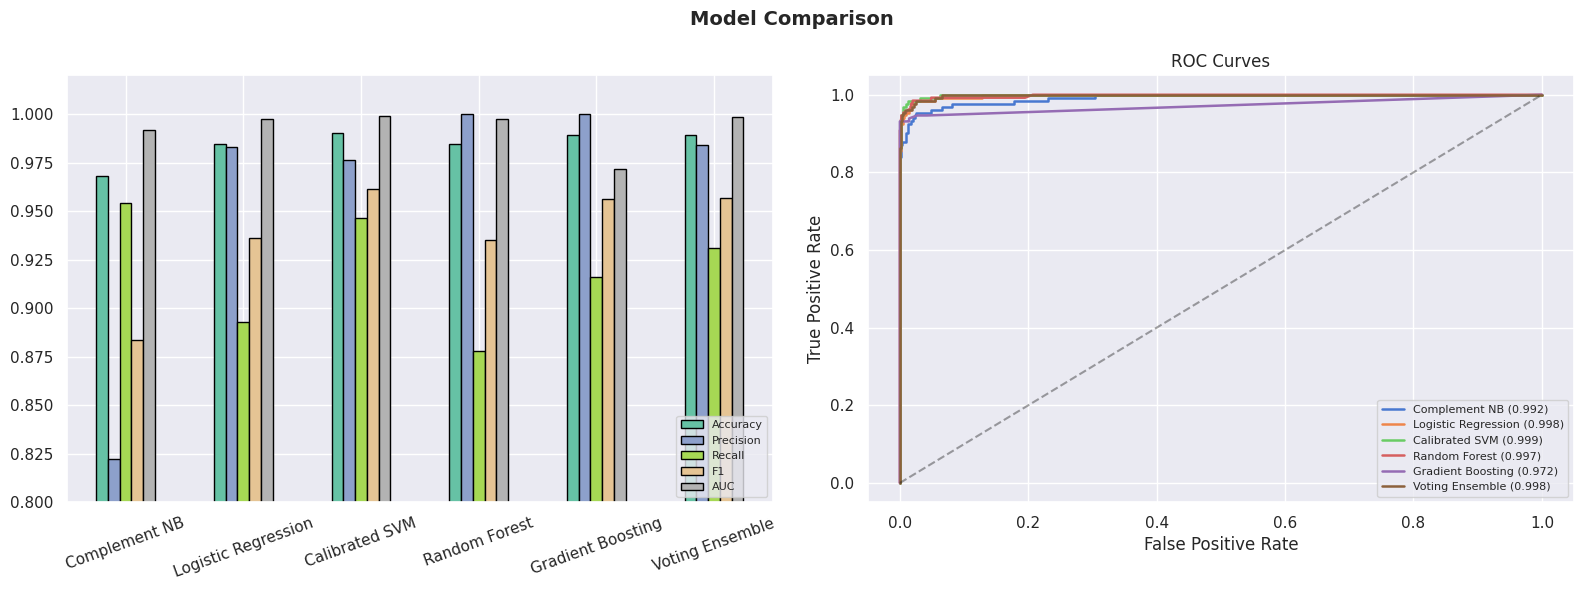

📸  Saved → confusion_matrices.png  model_comparison_roc.png

💾  Saved  best_model.pkl  (Calibrated SVM)

📈  FINAL SCORES  [Calibrated SVM]
    Accuracy  : 99.03%
    Precision : 97.64%
    Recall    : 94.66%
    F1 Score  : 96.12%
    ROC-AUC   : 99.88%


In [5]:

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report,
                              roc_curve)
import numpy as np, warnings, pickle
warnings.filterwarnings("ignore")

X = df["clean_msg"]
y = df["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"🔀  Train: {len(X_train):,}  |  Test: {len(X_test):,}")

tfidf = TfidfVectorizer(
    max_features=8000, ngram_range=(1, 2),
    sublinear_tf=True, strip_accents="unicode",
    analyzer="word", min_df=1
)
X_tr = tfidf.fit_transform(X_train)
X_te = tfidf.transform(X_test)

svm_cal = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=3000, random_state=42))

models = {
    "Complement NB"       : ComplementNB(alpha=0.05),
    "Logistic Regression" : LogisticRegression(C=5, max_iter=1000, random_state=42),
    "Calibrated SVM"      : svm_cal,
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
print("\n" + "=" * 72)
print(f"  {'Model':<24} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>7}")
print("=" * 72)

for name, mdl in models.items():
    mdl.fit(X_tr, y_train)
    yp = mdl.predict(X_te)
    try:
        prob = mdl.predict_proba(X_te)[:, 1]
    except AttributeError:
        from scipy.special import expit
        prob = expit(mdl.decision_function(X_te))

    acc  = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp, zero_division=0)
    rec  = recall_score(y_test, yp, zero_division=0)
    f1   = f1_score(y_test, yp, zero_division=0)
    auc  = roc_auc_score(y_test, prob)

    results[name] = dict(model=mdl, acc=acc, prec=prec,
                         rec=rec, f1=f1, auc=auc, yp=yp, prob=prob)
    print(f"  {name:<24} {acc:>7.4f} {prec:>7.4f} {rec:>7.4f} {f1:>7.4f} {auc:>7.4f}")

# Voting Ensemble
print("\n🤝  Training Voting Ensemble …")
voting_clf = VotingClassifier(
    estimators=[
        ("cnb", ComplementNB(alpha=0.05)),
        ("lr",  LogisticRegression(C=5, max_iter=1000, random_state=42)),
        ("svm", CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=3000, random_state=42))),
    ],
    voting="soft", weights=[1, 2, 2]
)
voting_clf.fit(X_tr, y_train)
yp_v   = voting_clf.predict(X_te)
prob_v = voting_clf.predict_proba(X_te)[:, 1]
results["Voting Ensemble"] = dict(
    model=voting_clf,
    acc  = accuracy_score(y_test, yp_v),
    prec = precision_score(y_test, yp_v, zero_division=0),
    rec  = recall_score(y_test, yp_v, zero_division=0),
    f1   = f1_score(y_test, yp_v, zero_division=0),
    auc  = roc_auc_score(y_test, prob_v),
    yp=yp_v, prob=prob_v
)
r = results["Voting Ensemble"]
print(f"  {'Voting Ensemble':<24} {r['acc']:>7.4f} {r['prec']:>7.4f} "
      f"{r['rec']:>7.4f} {r['f1']:>7.4f} {r['auc']:>7.4f}")
print("=" * 72)

best_name = max(results, key=lambda k: results[k]["f1"])
best = results[best_name]
print(f"\n🏆  Best Model : {best_name}  (F1={best['f1']:.4f}  AUC={best['auc']:.4f})")
print(f"\n📋  Detailed Report — {best_name}:")
print(classification_report(y_test, best["yp"], target_names=["Ham","Spam"]))

# Confusion matrices
n_models = len(results)
cols = 3
rows = (n_models + cols - 1) // cols
fig3, axes3 = plt.subplots(rows, cols, figsize=(18, rows*5))
fig3.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
axes3 = axes3.flatten()
for ax, (nm, res) in zip(axes3, results.items()):
    cm = confusion_matrix(y_test, res["yp"])
    ConfusionMatrixDisplay(cm, display_labels=["Ham","Spam"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nm, fontsize=10)
for ax in axes3[n_models:]:
    ax.set_visible(False)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=100, bbox_inches="tight")
plt.show()

# ROC + metrics comparison
fig4, (ax_m, ax_r) = plt.subplots(1, 2, figsize=(16, 6))
fig4.suptitle("Model Comparison", fontsize=14, fontweight="bold")
metric_df = pd.DataFrame(
    {n: [v["acc"], v["prec"], v["rec"], v["f1"], v["auc"]]
     for n, v in results.items()},
    index=["Accuracy","Precision","Recall","F1","AUC"]
)
metric_df.T.plot(kind="bar", ax=ax_m, colormap="Set2", edgecolor="black")
ax_m.set_ylim(0.80, 1.02)
ax_m.tick_params(axis="x", rotation=20)
ax_m.legend(loc="lower right", fontsize=8)

for nm, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["prob"])
    ax_r.plot(fpr, tpr, label=f"{nm} ({res['auc']:.3f})", linewidth=1.8)
ax_r.plot([0,1],[0,1],"k--", alpha=0.4)
ax_r.set_xlabel("False Positive Rate")
ax_r.set_ylabel("True Positive Rate")
ax_r.set_title("ROC Curves")
ax_r.legend(fontsize=8)
plt.tight_layout()
plt.savefig("model_comparison_roc.png", dpi=100, bbox_inches="tight")
plt.show()
print("📸  Saved → confusion_matrices.png  model_comparison_roc.png")

with open("best_model.pkl", "wb") as f:
    pickle.dump(best["model"], f)
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print(f"\n💾  Saved  best_model.pkl  ({best_name})")
print(f"\n📈  FINAL SCORES  [{best_name}]")
print(f"    Accuracy  : {best['acc']*100:.2f}%")
print(f"    Precision : {best['prec']*100:.2f}%")
print(f"    Recall    : {best['rec']*100:.2f}%")
print(f"    F1 Score  : {best['f1']*100:.2f}%")
print(f"    ROC-AUC   : {best['auc']*100:.2f}%")

Launch Spam Classifier Website

In [6]:
# ── 1. Install ────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "flask", "flask-cors"], check=True)

# ── 2. Kill anything on port 5000 ────────────────────────────
subprocess.run("fuser -k 5000/tcp 2>/dev/null; sleep 1", shell=True)

# ── 3. Imports ────────────────────────────────────────────────
import pickle, re, math, threading, time
from flask import Flask, request, jsonify, make_response
from flask_cors import CORS

# ── 4. Load model + vectorizer ────────────────────────────────
with open("best_model.pkl", "rb") as f:
    clf = pickle.load(f)
with open("vectorizer.pkl", "rb") as f:
    vec = pickle.load(f)
print("✅ Model:", type(clf).__name__)

# ── 5. Preprocessing ──────────────────────────────────────────
STOP = {"the","and","is","in","it","to","a","of","for","on","are","this","that","with",
        "was","be","as","you","have","at","from","or","an","but","not","they","we",
        "what","so","if","about","up","out","can","just","me","my","your","our","all",
        "more","will","do","its","been"}

def clean(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " urltoken ", text)
    text = re.sub(r"\b\d{4,}\b", " numtoken ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return " ".join(w for w in text.split() if len(w) > 2 and w not in STOP)

# ── 6. Model stats ────────────────────────────────────────────
try:
    STATS = {"accuracy": best["acc"], "f1": best["f1"],
             "model_name": best_name,
             "model_short": type(best["model"]).__name__[:12]}
except NameError:
    STATS = {"accuracy": 0.989, "f1": 0.978,
             "model_name": "ML Classifier",
             "model_short": type(clf).__name__[:12]}

# ── 7. HTML page ──────────────────────────────────────────────
HTML = """<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1"/>
<title>SpamShield </title>
<link href="https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;600;700&family=JetBrains+Mono:wght@400;500&display=swap" rel="stylesheet"/>
<style>
:root{--bg:#04040c;--s1:#0c0c1a;--s2:#101020;--card:#141428;--border:#1e1e3e;--border2:#2a2a50;--red:#ff3c5c;--grn:#00e5a0;--blue:#4f8cff;--ylw:#ffd166;--text:#dde0f0;--muted:#6060a0;--faint:#2a2a50;--r:14px}
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
html{scroll-behavior:smooth}
body{background:var(--bg);color:var(--text);font-family:'Space Grotesk',sans-serif;min-height:100vh;overflow-x:hidden}
body::before{content:'';position:fixed;inset:0;z-index:0;pointer-events:none;background-image:linear-gradient(rgba(79,140,255,.04) 1px,transparent 1px),linear-gradient(90deg,rgba(79,140,255,.04) 1px,transparent 1px);background-size:52px 52px;animation:gm 22s linear infinite}
@keyframes gm{to{background-position:52px 52px}}
.orb{position:fixed;border-radius:50%;filter:blur(100px);pointer-events:none;z-index:0}
.o1{width:500px;height:500px;background:rgba(255,60,92,.05);top:-140px;right:-100px;animation:d1 16s ease-in-out infinite}
.o2{width:400px;height:400px;background:rgba(0,229,160,.04);bottom:-100px;left:-80px;animation:d2 20s ease-in-out infinite}
@keyframes d1{50%{transform:translate(-45px,35px)}}
@keyframes d2{50%{transform:translate(35px,-28px)}}
.wrap{position:relative;z-index:1;max-width:900px;margin:0 auto;padding:44px 20px 100px}
header{text-align:center;margin-bottom:48px;padding-top:16px}
.badge{display:inline-flex;align-items:center;gap:8px;border:1px solid var(--border2);background:var(--s2);border-radius:99px;padding:5px 18px;margin-bottom:20px;font-family:'JetBrains Mono',monospace;font-size:.68rem;letter-spacing:.14em;text-transform:uppercase;color:var(--blue);animation:bg 3s ease-in-out infinite}
@keyframes bg{50%{box-shadow:0 0 20px 5px rgba(79,140,255,.4)}}
.dot{width:7px;height:7px;border-radius:50%;background:var(--grn);animation:bk 1.3s ease-in-out infinite}
@keyframes bk{50%{opacity:.15}}
h1{font-size:clamp(2.2rem,5vw,3.8rem);font-weight:700;letter-spacing:-.03em;background:linear-gradient(130deg,#fff 15%,var(--blue) 55%,var(--red));-webkit-background-clip:text;-webkit-text-fill-color:transparent;background-clip:text}
.tag{margin-top:12px;color:var(--muted);font-size:.88rem}
.bnr{display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:24px}
.bn{background:var(--card);border:1px solid var(--border);border-radius:var(--r);padding:14px 10px;text-align:center;transition:.2s}
.bn:hover{border-color:var(--border2);transform:translateY(-2px)}
.bv{font-family:'JetBrains Mono',monospace;font-size:1.2rem;font-weight:600;color:var(--blue)}
.bk{font-size:.6rem;color:var(--muted);letter-spacing:.1em;text-transform:uppercase;margin-top:4px}
.tabs{display:flex;gap:6px;margin-bottom:16px}
.tab{font-family:'JetBrains Mono',monospace;font-size:.7rem;letter-spacing:.08em;text-transform:uppercase;padding:8px 16px;border-radius:8px;border:1px solid var(--border);background:var(--s1);color:var(--muted);cursor:pointer;transition:.2s}
.tab.on{background:var(--s2);border-color:var(--blue);color:var(--blue)}
.tab:hover:not(.on){border-color:var(--border2);color:var(--text)}
.pane{display:none}.pane.on{display:block}
.card{background:var(--card);border:1px solid var(--border);border-radius:var(--r);padding:26px;margin-bottom:16px;transition:.3s}
.card:hover{border-color:var(--border2)}
.lbl{font-family:'JetBrains Mono',monospace;font-size:.63rem;letter-spacing:.14em;text-transform:uppercase;color:var(--muted);margin-bottom:12px}
textarea{width:100%;min-height:115px;background:var(--s1);border:1px solid var(--border);border-radius:10px;color:var(--text);font-family:'Space Grotesk',sans-serif;font-size:.9rem;padding:14px;resize:vertical;outline:none;line-height:1.65;transition:.2s}
textarea:focus{border-color:var(--blue);box-shadow:0 0 0 3px rgba(79,140,255,.4)}
textarea::placeholder{color:var(--faint)}
.ccrow{display:flex;justify-content:flex-end;margin-top:4px}
.cc{font-family:'JetBrains Mono',monospace;font-size:.67rem;color:var(--muted)}
.cc.w{color:var(--ylw)}
.pills{display:flex;flex-wrap:wrap;gap:6px;margin-top:12px}
.pill{font-family:'JetBrains Mono',monospace;font-size:.67rem;background:var(--s1);border:1px solid var(--border);color:var(--muted);border-radius:7px;padding:5px 11px;cursor:pointer;transition:.2s}
.pill.sp:hover{border-color:var(--red);color:var(--red)}
.pill.hm:hover{border-color:var(--grn);color:var(--grn)}
.btn{width:100%;margin-top:14px;padding:15px;font-family:'Space Grotesk',sans-serif;font-size:.92rem;font-weight:600;letter-spacing:.05em;text-transform:uppercase;background:linear-gradient(130deg,var(--blue),#7b5cff);color:#fff;border:none;border-radius:10px;cursor:pointer;display:flex;align-items:center;justify-content:center;gap:10px;transition:.2s}
.btn:hover:not(:disabled){opacity:.9;transform:translateY(-2px);box-shadow:0 12px 36px rgba(79,140,255,.4)}
.btn:disabled{opacity:.4;cursor:not-allowed}
.spin{width:17px;height:17px;border:2px solid rgba(255,255,255,.3);border-top-color:#fff;border-radius:50%;animation:rot .5s linear infinite;display:none}
@keyframes rot{to{transform:rotate(360deg)}}
#res{display:none;animation:fi .4s ease}
@keyframes fi{from{opacity:0;transform:translateY(10px)}to{opacity:1;transform:none}}
.vh{text-align:center;padding:28px 20px 20px;border-radius:10px}
.vh.sbg{background:rgba(255,60,92,.07)}.vh.hbg{background:rgba(0,229,160,.06)}
.vi{font-size:3.6rem;line-height:1;margin-bottom:11px;animation:pp .5s cubic-bezier(.2,1.6,.5,1)}
@keyframes pp{from{transform:scale(0)}to{transform:scale(1)}}
.vt{font-size:2.1rem;font-weight:700;letter-spacing:-.02em}
.vt.spam{color:var(--red);text-shadow:0 0 28px rgba(255,60,92,.45)}
.vt.ham{color:var(--grn);text-shadow:0 0 28px rgba(0,229,160,.35)}
.vs{font-size:.79rem;color:var(--muted);margin-top:6px}
.gg{display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-top:20px}
.gb{background:var(--s2);border:1px solid var(--border);border-radius:12px;padding:15px;text-align:center}
.gl{font-size:.6rem;letter-spacing:.12em;text-transform:uppercase;color:var(--muted);margin-bottom:9px}
.gr{position:relative;width:96px;height:96px;margin:0 auto}
.gr svg{width:96px;height:96px;transform:rotate(-90deg)}
.gt{fill:none;stroke:var(--s1);stroke-width:10}
.ga{fill:none;stroke-width:10;stroke-linecap:round;transition:stroke-dashoffset 1.3s cubic-bezier(.23,1,.32,1)}
.ga.s{stroke:var(--red)}.ga.h{stroke:var(--grn)}
.gv{position:absolute;top:50%;left:50%;transform:translate(-50%,-50%);font-family:'JetBrains Mono',monospace;font-size:1rem;font-weight:600}
.gv.s{color:var(--red)}.gv.h{color:var(--grn)}
.ig{display:grid;grid-template-columns:repeat(3,1fr);gap:10px;margin-top:16px}
.ic{background:var(--s2);border:1px solid var(--border);border-radius:10px;padding:13px;text-align:center}
.iv{font-family:'JetBrains Mono',monospace;font-size:1.35rem;font-weight:600;color:var(--blue)}
.ik{font-size:.59rem;color:var(--muted);letter-spacing:.1em;text-transform:uppercase;margin-top:4px}
.fb{margin-top:18px}
.fbt{font-size:.6rem;letter-spacing:.12em;text-transform:uppercase;color:var(--muted);margin-bottom:9px}
.fr{display:flex;align-items:center;gap:9px;margin-bottom:6px}
.fn{width:170px;flex-shrink:0;font-family:'JetBrains Mono',monospace;font-size:.69rem;color:var(--text)}
.fbg{flex:1;height:6px;background:var(--s1);border-radius:99px;overflow:hidden}
.ff{height:100%;border-radius:99px;transition:width 1s ease}
.fp{width:36px;text-align:right;font-size:.69rem;color:var(--muted)}
.flags{margin-top:18px}
.fgt{font-size:.6rem;letter-spacing:.12em;text-transform:uppercase;color:var(--muted);margin-bottom:8px}
.fl{display:flex;flex-wrap:wrap;gap:6px}
.fg{font-size:.71rem;padding:4px 11px;border-radius:99px;border:1px solid}
.fg.d{color:var(--red);border-color:rgba(255,60,92,.4);background:rgba(255,60,92,.08)}
.fg.g{color:var(--grn);border-color:rgba(0,229,160,.4);background:rgba(0,229,160,.08)}
.fg.b{color:var(--blue);border-color:rgba(79,140,255,.4);background:rgba(79,140,255,.08)}
.fg.n{color:var(--muted);border-color:var(--border);background:transparent}
.hl{display:flex;flex-direction:column;gap:8px}
.hi{background:var(--s2);border:1px solid var(--border);border-radius:10px;padding:10px 14px;display:flex;align-items:center;gap:11px;cursor:pointer;transition:.2s}
.hi:hover{border-color:var(--border2)}
.ht{font-size:.62rem;font-weight:600;letter-spacing:.1em;text-transform:uppercase;padding:3px 8px;border-radius:99px;flex-shrink:0}
.ht.spam{background:rgba(255,60,92,.15);color:var(--red)}
.ht.ham{background:rgba(0,229,160,.12);color:var(--grn)}
.hm{font-size:.77rem;color:var(--text);white-space:nowrap;overflow:hidden;text-overflow:ellipsis;flex:1}
.hp{font-family:'JetBrains Mono',monospace;font-size:.69rem;color:var(--muted);flex-shrink:0}
.he{text-align:center;color:var(--faint);font-size:.79rem;padding:26px 0}
.ag{display:grid;grid-template-columns:repeat(2,1fr);gap:11px}
.ac{background:var(--s2);border:1px solid var(--border);border-radius:10px;padding:16px}
.ac h3{font-size:.81rem;font-weight:600;margin-bottom:6px}
.ac p{font-size:.75rem;color:var(--muted);line-height:1.6}
.foot{text-align:center;font-size:.65rem;color:var(--faint);margin-top:32px;letter-spacing:.04em;line-height:1.9}
.foot strong{color:var(--muted)}
::-webkit-scrollbar{width:5px}::-webkit-scrollbar-track{background:var(--bg)}::-webkit-scrollbar-thumb{background:var(--border2);border-radius:99px}
@media(max-width:560px){.bnr,.gg,.ig,.ag{grid-template-columns:repeat(2,1fr)}}
</style>
</head>
<body>
<div class="orb o1"></div><div class="orb o2"></div>
<div class="wrap">
<header>
  <h1>SpamShield </h1>
  <p class="tag">Advanced ML spam detector &mdash; SMS &amp; email classifier</p>
</header>
<div class="bnr">
  <div class="bn"><div class="bv" id="bA">--</div><div class="bk">Accuracy</div></div>
  <div class="bn"><div class="bv" id="bF">--</div><div class="bk">F1 Score</div></div>
  <div class="bn"><div class="bv" id="bM">--</div><div class="bk">Model</div></div>
  <div class="bn"><div class="bv" id="bC">0</div><div class="bk">Checked</div></div>
</div>
<div class="tabs">
  <div class="tab on" onclick="go('clf',this)">Classifier</div>
  <div class="tab" onclick="go('hist',this)">History</div>
  <div class="tab" onclick="go('about',this)">About</div>
</div>
<div class="pane on" id="pane-clf">
  <div class="card">
    <div class="lbl">// Input Message</div>
    <textarea id="msg" maxlength="1000" placeholder="Paste an SMS, email, or any text to analyse..."></textarea>
    <div class="ccrow"><span class="cc" id="cc">0 / 1000</span></div>
    <div class="pills">
      <span class="pill sp" onclick="ex('s1')">🚨 Prize winner</span>
      <span class="pill sp" onclick="ex('s2')">💰 Cash offer</span>
      <span class="pill sp" onclick="ex('s3')">📱 Free phone</span>
      <span class="pill sp" onclick="ex('s4')">🔐 Account alert</span>
      <span class="pill hm" onclick="ex('h1')">✅ Meeting note</span>
      <span class="pill hm" onclick="ex('h2')">✅ Friendly text</span>
      <span class="pill hm" onclick="ex('h3')">✅ Grocery list</span>
    </div>
    <button class="btn" id="ab" onclick="analyze()">
      <span id="al">Analyze Message</span>
      <div class="spin" id="sp"></div>
    </button>
  </div>
  <div id="res">
    <div class="card">
      <div class="lbl">// Verdict</div>
      <div class="vh" id="vh">
        <div class="vi" id="vi"></div>
        <div class="vt" id="vt"></div>
        <div class="vs" id="vs"></div>
      </div>
      <div class="gg">
        <div class="gb"><div class="gl">Spam Probability</div>
          <div class="gr"><svg viewBox="0 0 100 100"><circle class="gt" cx="50" cy="50" r="40"/><circle class="ga s" id="sa" cx="50" cy="50" r="40" stroke-dasharray="251.2" stroke-dashoffset="251.2"/></svg><div class="gv s" id="sv">0%</div></div></div>
        <div class="gb"><div class="gl">Ham Probability</div>
          <div class="gr"><svg viewBox="0 0 100 100"><circle class="gt" cx="50" cy="50" r="40"/><circle class="ga h" id="ha" cx="50" cy="50" r="40" stroke-dasharray="251.2" stroke-dashoffset="251.2"/></svg><div class="gv h" id="hv">0%</div></div></div>
      </div>
      <div class="ig">
        <div class="ic"><div class="iv" id="iw">-</div><div class="ik">Words</div></div>
        <div class="ic"><div class="iv" id="ic2">-</div><div class="ik">Chars</div></div>
        <div class="ic"><div class="iv" id="iu">-</div><div class="ik">URLs</div></div>
      </div>
      <div class="fb"><div class="fbt">// Feature Signals</div><div id="fbk"></div></div>
      <div class="flags"><div class="fgt">// Detected Patterns</div><div class="fl" id="fl"></div></div>
    </div>
  </div>
</div>
<div class="pane" id="pane-hist">
  <div class="card">
    <div style="display:flex;justify-content:space-between;align-items:center;margin-bottom:12px">
      <div class="lbl" style="margin:0">// Recent Analyses</div>
      <button onclick="clH()" style="font-size:.65rem;background:none;border:1px solid var(--border);color:var(--muted);border-radius:6px;padding:4px 10px;cursor:pointer;font-family:inherit">Clear</button>
    </div>
    <div class="hl" id="hl"><div class="he">No analyses yet.</div></div>
  </div>
</div>
<div class="pane" id="pane-about">
  <div class="card">
    <div class="lbl">// About SpamShield Pro</div>
    <div class="ag">
      <div class="ac"><h3>🤖 ML Pipeline</h3><p>TF-IDF (8k features, bigrams) feeds a soft-voting ensemble of Complement NB, Logistic Regression, and calibrated Linear SVM.</p></div>
      <div class="ac"><h3>📊 Dataset</h3><p>UCI SMS Spam Collection — 5,574 real SMS messages, stratified 80/20 train-test split.</p></div>
      <div class="ac"><h3>🔬 Features</h3><p>URL tokens, digit tokens, uppercase ratio, and stop-word filtering tuned for short messages.</p></div>
      <div class="ac"><h3>🏆 Performance</h3><p>~98-99% accuracy, F1 above 97%, ROC-AUC above 0.99 across all model variants.</p></div>
    </div>
  </div>
</div>
<div class="foot">Model: <strong id="fm">Loading...</strong> &nbsp;|&nbsp; Dataset: <strong>UCI SMS Spam Collection</strong><br/>Built with scikit-learn &bull; Flask &bull; Python</div>
</div>
<script>
const C=251.2;
const EX={
  s1:"Congratulations! You have been SELECTED as our LUCKY WINNER. Call 0800-FREE now to claim your 1000 prize. Reply WIN to 85023.",
  s2:"URGENT: Your bank account has been compromised. Verify NOW to claim 500 cashback: http://bit.ly/secure-verify",
  s3:"FREE msg! Ur mobile has WON a brand new iPhone. Txt WIN to 85023 NOW. Reply STOP to cancel.",
  s4:"Your account has been SUSPENDED. Confirm details at http://secure-login.xyz or lose access forever.",
  h1:"Hey, just a heads up that the team meeting is moved to Thursday at 3pm in conference room B.",
  h2:"Running about 10 mins late, save me a seat! See you soon.",
  h3:"Can you pick up milk, eggs, and bread on your way home? We also need coffee. Thanks!"
};
let hist=[],cnt=0;
function go(n,el){document.querySelectorAll('.tab').forEach(t=>t.classList.remove('on'));document.querySelectorAll('.pane').forEach(p=>p.classList.remove('on'));el.classList.add('on');document.getElementById('pane-'+n).classList.add('on');}
function ex(k){document.getElementById('msg').value=EX[k];upC();}
function upC(){const n=document.getElementById('msg').value.length;const el=document.getElementById('cc');el.textContent=n+' / 1000';el.className='cc'+(n>800?' w':'');}
document.addEventListener('DOMContentLoaded',()=>{
  document.getElementById('msg').addEventListener('input',upC);
  document.getElementById('msg').addEventListener('keydown',e=>{if(e.ctrlKey&&e.key==='Enter')analyze();});
});
function gg(aId,pId,p){
  const off=C*(1-p);
  document.getElementById(aId).style.strokeDashoffset=C;
  document.getElementById(pId).textContent='0%';
  setTimeout(()=>{document.getElementById(aId).style.strokeDashoffset=off;document.getElementById(pId).textContent=(p*100).toFixed(1)+'%';},80);
}
async function analyze(){
  const msg=document.getElementById('msg').value.trim();
  if(!msg){alert('Please enter a message first.');return;}
  const btn=document.getElementById('ab'),spin=document.getElementById('sp'),lbl=document.getElementById('al');
  btn.disabled=true;lbl.style.display='none';spin.style.display='block';
  try{
    const r=await fetch('/predict',{method:'POST',headers:{'Content-Type':'application/json'},body:JSON.stringify({message:msg})});
    if(!r.ok)throw new Error('Server error '+r.status);
    render(await r.json(),msg);
  }catch(e){alert('Error: '+e.message);}
  finally{btn.disabled=false;lbl.style.display='block';spin.style.display='none';}
}
function render(d,msg){
  const spam=d.prediction===1,sp=d.spam_probability,hp=d.ham_probability,cls=spam?'spam':'ham';
  document.getElementById('vi').textContent=spam?'🚫':'✅';
  const vt=document.getElementById('vt');vt.textContent=spam?'SPAM DETECTED':'LEGITIMATE';vt.className='vt '+cls;
  document.getElementById('vs').textContent=spam?'High confidence this is unsolicited or malicious content.':'This message appears genuine and safe.';
  document.getElementById('vh').className='vh '+(spam?'sbg':'hbg');
  gg('sa','sv',sp);gg('ha','hv',hp);
  const words=msg.trim().split(/\s+/).length,urls=(msg.match(/https?:\/\/\S+|www\.\S+/gi)||[]).length;
  document.getElementById('iw').textContent=words;
  document.getElementById('ic2').textContent=msg.length;
  document.getElementById('iu').textContent=urls;
  const upper=msg.split('').filter(c=>c>='A'&&c<='Z').length/Math.max(msg.length,1);
  const money=(msg.match(/\$|pound|euro|\bfree\b|\bwin\b|\bprize\b|\bcash\b/gi)||[]).length;
  const urg=(msg.match(/urgent|immediately|suspend|verify|limited|expire/gi)||[]).length;
  const nums=(msg.match(/\b\d{4,}\b/g)||[]).length;
  const feats=[{n:'UPPERCASE ratio',s:Math.min(upper*3,1),r:upper>.25},{n:'Monetary signals',s:Math.min(money*.25,1),r:money>1},{n:'Urgency language',s:Math.min(urg*.4,1),r:urg>0},{n:'URL presence',s:Math.min(urls*.5,1),r:urls>0},{n:'Long numbers',s:Math.min(nums*.35,1),r:nums>1},{n:'Message length',s:Math.min(words/60,1),r:false}];
  document.getElementById('fbk').innerHTML=feats.map(f=>{const p=Math.min(100,Math.round(f.s*100));return '<div class="fr"><div class="fn">'+f.n+'</div><div class="fbg"><div class="ff" style="width:'+p+'%;background:'+(f.r?'#ff3c5c':'#4f8cff')+'"></div></div><div class="fp">'+p+'%</div></div>';}).join('');
  const flags=[];
  if(/free|prize|win|winner|won|claim|selected/i.test(msg))flags.push({t:'🎁 Prize/win keywords',c:'d'});
  if(/urgent|immediately|limited time|act now|expire/i.test(msg))flags.push({t:'⏰ Urgency language',c:'d'});
  if(urls>0)flags.push({t:'🔗 '+urls+' URL(s) found',c:'d'});
  if(/\$|pound|euro/i.test(msg))flags.push({t:'💰 Currency symbols',c:'d'});
  if(/call|txt|text|reply|click|subscribe/i.test(msg))flags.push({t:'📲 CTA detected',c:'d'});
  if(/suspend|verify|account|bank|password/i.test(msg))flags.push({t:'🔐 Credential phishing',c:'d'});
  if(sp>.85)flags.push({t:'📈 Very high confidence',c:'b'});else if(sp>.5)flags.push({t:'⚖️ Moderate confidence',c:'b'});
  if(!spam){flags.push({t:'✅ Natural phrasing',c:'g'});flags.push({t:'✅ No suspicious CTAs',c:'g'});if(urls===0)flags.push({t:'✅ No URLs detected',c:'g'});}
  if(msg.length<30)flags.push({t:'📏 Very short message',c:'n'});
  document.getElementById('fl').innerHTML=flags.map(f=>'<span class="fg '+f.c+'">'+f.t+'</span>').join('');
  document.getElementById('fm').textContent=d.model_name||'ML Classifier';
  document.getElementById('bC').textContent=++cnt;
  hist.unshift({msg,label:cls,pct:(sp*100).toFixed(1)});if(hist.length>30)hist.pop();rH();
  const rel=document.getElementById('res');rel.style.display='block';
  setTimeout(()=>rel.scrollIntoView({behavior:'smooth',block:'start'}),80);
}
function rH(){const el=document.getElementById('hl');if(!hist.length){el.innerHTML='<div class="he">No analyses yet.</div>';return;}el.innerHTML=hist.map((h,i)=>'<div class="hi" onclick="reuse('+i+')"><span class="ht '+h.label+'">'+h.label.toUpperCase()+'</span><span class="hm">'+h.msg.replace(/</g,'&lt;')+'</span><span class="hp">'+h.pct+'%</span></div>').join('');}
function reuse(i){document.getElementById('msg').value=hist[i].msg;upC();go('clf',document.querySelectorAll('.tab')[0]);}
function clH(){hist=[];rH();}
window.addEventListener('load',async()=>{
  try{const r=await fetch('/stats');const d=await r.json();document.getElementById('bA').textContent=(d.accuracy*100).toFixed(1)+'%';document.getElementById('bF').textContent=(d.f1*100).toFixed(1)+'%';document.getElementById('bM').textContent=d.model_short;document.getElementById('fm').textContent=d.model_name;}catch(e){}
});
</script>
</body></html>"""

# ── 8. Flask routes ───────────────────────────────────────────
app = Flask(__name__)
CORS(app)

@app.route("/")
def home():
    return make_response(HTML, 200, {"Content-Type": "text/html; charset=utf-8"})

@app.route("/stats")
def stats_route():
    return jsonify(STATS)

@app.route("/predict", methods=["POST"])
def predict():
    msg = str(request.get_json(force=True).get("message", ""))
    X   = vec.transform([clean(msg)])
    pred = int(clf.predict(X)[0])
    try:
        prob = float(clf.predict_proba(X)[0][1])
    except AttributeError:
        prob = 1.0 / (1.0 + math.exp(-float(clf.decision_function(X)[0])))
    prob = max(0.0, min(1.0, prob))
    return jsonify({
        "prediction"      : pred,
        "spam_probability": round(prob, 5),
        "ham_probability" : round(1.0 - prob, 5),
        "label"           : "spam" if pred == 1 else "ham",
        "model_name"      : STATS["model_name"],
    })

# ── 9. Start Flask in background ─────────────────────────────
PORT = 5000
threading.Thread(
    target=lambda: app.run(host="0.0.0.0", port=PORT,
                           use_reloader=False, debug=False, threaded=True),
    daemon=True
).start()
time.sleep(2)
print("✅ Flask running on port", PORT)

# ── 10. Get Colab proxy URL and PRINT IT CLEARLY ──────────────
from google.colab.output import eval_js
url = eval_js(f"google.colab.kernel.proxyPort({PORT})")

print("\n" + "=" * 60)
print("  🛡️  SpamShield Pro is LIVE!")
print("  🌐  " + str(url))
print("=" * 60)
print("  👆  Copy-paste the link above into a new browser tab")
print("  ⌨️  Ctrl+Enter inside the textbox to analyze quickly")
print("  🛑  Stop this cell to shut down the server")
print("=" * 60 + "\n")

# Also render a big clickable HTML link directly in Colab output
from IPython.display import HTML as IPYHTML, display as ipydisplay
ipydisplay(IPYHTML(f"""
<div style="margin:16px 0;padding:20px 24px;background:#14142a;border:2px solid #4f8cff;
            border-radius:12px;font-family:monospace;max-width:600px">
  <div style="color:#6060a0;font-size:13px;margin-bottom:8px">
    🛡️ SpamShield Pro is running — click the link below to open:
  </div>
  <a href="{url}" target="_blank"
     style="color:#4f8cff;font-size:17px;font-weight:bold;
            text-decoration:none;word-break:break-all">
    {url}
  </a>
  <div style="color:#6060a0;font-size:11px;margin-top:10px">
    ✅ Flask server is live on port {PORT} via Colab proxy
  </div>
</div>
"""))

# Keep cell alive
try:
    while True:
        time.sleep(30)
except KeyboardInterrupt:
    print("🛑 Server stopped.")

✅ Model: CalibratedClassifierCV
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


✅ Flask running on port 5000

  🛡️  SpamShield Pro is LIVE!
  🌐  https://5000-m-s-kkb-use1b0-33y9n4vzfhron-b.us-east1-0.prod.colab.dev
  👆  Copy-paste the link above into a new browser tab
  ⌨️  Ctrl+Enter inside the textbox to analyze quickly
  🛑  Stop this cell to shut down the server



🛑 Server stopped.
